In [4]:
import numpy as np
import pandas as pd

In [14]:
import numpy as np
import argparse
import os
from astropy import units as u
from astropy.coordinates import EarthLocation, AltAz, SkyCoord, get_sun
from scipy.interpolate import griddata
from astropy.time import Time
from pytz import timezone
from datetime import datetime, timedelta
import pygdsm
import healpy as hp
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap, LogNorm

# CASM Array Parameters
N_ROWS = 43   # North-South
N_COLS = 6   # East-West
N_ANTENNAS = N_ROWS * N_COLS  # 30 antennas
N_POL = 1    # Two polarizations per antenna
ARRAY_NS_LENGTH = 21.  # meters (North-South)
ARRAY_EW_LENGTH = 2.4   # meters (East-West)
FREQ_MIN = 375.0  # MHz
FREQ_MAX = 468.0  # MHz (375 + 93 MHz bandwidth)
FREQ_CENTER = (FREQ_MIN + FREQ_MAX) / 2.0  # MHz

C_LIGHT = 299792458.0    # Speed of light in m/s
K_BOLTZMANN = 1.380649e-23 # Boltzmann constant in J/K

# OVRO location (approximate coordinates for Owens Valley Radio Observatory)
OVRO_LAT = 37.2339  # degrees
OVRO_LON = -118.2817  # degrees
OVRO_ELEV = 1222.0  # meters

# Primary beam solid angle (near zenith)
PRIMARY_BEAM_SOLID_ANGLE = 7500.0  # square degrees


# --- SUN MODEL PARAMETERS ---
SUN_BRIGHTNESS_TEMP = 8.0e5  # K (Approximation for Quiet Sun T_b)
SUN_DIAMETER_DEG = 1.2       # degrees (Approximation for size at 400 MHz)
SUN_SIGMA_DEG = SUN_DIAMETER_DEG / 2.355  # FWHM to Gaussian sigma: sigma = FWHM / (2*sqrt(2*ln(2)))
# -----------------------------


def generate_antenna_positions():
    """
    Generate spatial positions for the 43x6 grid of antennas.
    Returns positions in local ENU (East-North-Up) coordinates in meters.
    """
    # Create grid indices
    row_indices = np.arange(N_ROWS)  # 0 to N_ROWS-1
    col_indices = np.arange(N_COLS)  # 0 to N_COLS-1
    
    # Calculate spacing
    ns_spacing = ARRAY_NS_LENGTH / (N_ROWS - 1) if N_ROWS > 1 else 0
    ew_spacing = ARRAY_EW_LENGTH / (N_COLS - 1) if N_COLS > 1 else 0
    
    # Generate positions in local coordinates (East, North, Up)
    # East is x, North is y, Up is z
    positions = np.zeros((N_ANTENNAS, 3))
    
    idx = 0
    for row in row_indices:
        for col in col_indices:
            # Position relative to array center
            # East (x): col * spacing - center_offset
            # North (y): row * spacing - center_offset
            # Up (z): 0.24 m above ground screen
            positions[idx, 0] = col * ew_spacing #- ARRAY_EW_LENGTH / 2.0  # East
            positions[idx, 1] = -row * ns_spacing #- ARRAY_NS_LENGTH / 2.0  # North
            positions[idx, 2] = 0  # Up (24 cm above ground screen)
            idx += 1
    
    return positions

In [15]:
pos = generate_antenna_positions()

In [17]:
pos.shape

(258, 3)

In [18]:
df = pd.DataFrame(pos)

In [19]:
df.to_csv("casm-258.csv")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from astropy.time import Time, TimeDelta
import datetime
plt.style.use('default')
plt.style.use(['science', 'notebook'])
import glob
import os
import re
import pytz
import pandas as pd
from astropy.stats import sigma_clip
from scipy.interpolate import griddata

In [2]:
# mod_vis_full = np.load("/home/casm/software/casm_xengine/scripts/advait/vis-sim/results_20260218_0800_to_20260219_0800/casm_visibilities_20260218_0800_to_20260219_0800.npz")
# mod_vis_full = np.load("/home/casm/software/casm_xengine/scripts/advait/vis-sim/results_20260218_0801_to_20260219_0801/casm_visibilities_20260218_0801_to_20260219_0801.npz")
# mod_vis_full = np.load("/home/casm/software/casm_xengine/scripts/advait/vis-sim/results_20260219_0800_to_20260220_0800/casm_visibilities_20260219_0800_to_20260220_0800.npz")
mod_vis_full = np.load("/home/casm/software/casm_xengine/scripts/advait/vis-sim/results_casm-60_20260225_1200_to_20260225_1300/casm_visibilities_casm-60_20260225_1200_to_20260225_1300.npz")

In [3]:
# Unpack all data from the NPZ file
mod_vis = mod_vis_full['visibilities']
mod_times = mod_vis_full['times']
baseline_pairs = mod_vis_full['baseline_pairs']
baseline_vecs = mod_vis_full['baselines']  
mod_freqs = mod_vis_full['frequencies']
src_alts = mod_vis_full['source_alt']  
src_azs = mod_vis_full['source_az']  
source_names = mod_vis_full['source_names']
antenna_positions = mod_vis_full['antenna_positions']
uvw_coords = mod_vis_full['uvw']
# Additional antenna mapping data
n_antennas = mod_vis_full['n_antennas']
n_pol = mod_vis_full['n_pol']
array_shape = mod_vis_full['array_shape']
array_dimensions = mod_vis_full['array_dimensions']
antenna_ids = mod_vis_full['antenna_ids']
row_indices = mod_vis_full['row_indices']
col_indices = mod_vis_full['col_indices']

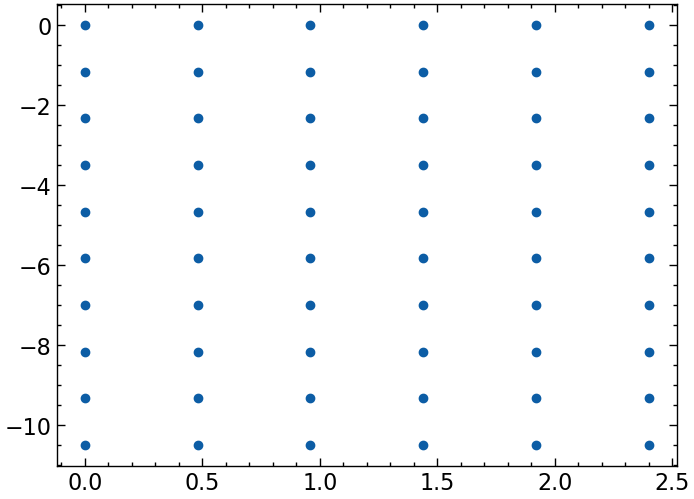

In [4]:
plt.scatter(antenna_positions[:,0], antenna_positions[:,1])

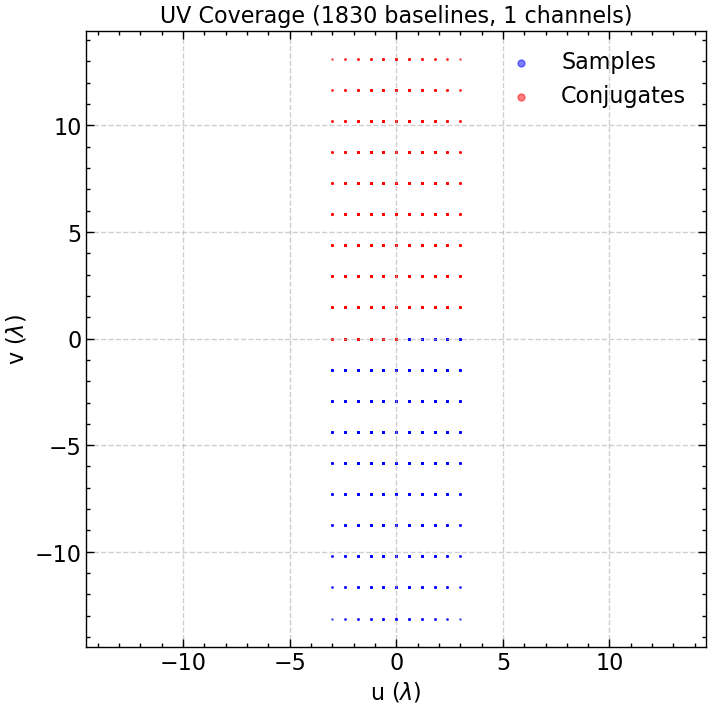

In [5]:
def plot_uv_coverage(uvw_lambda):
    """
    Plots the UV coverage from uvw_coords.
    uvw_lambda: shape (baseline, freq, 3)
    """
    # 1. Extract U and V components
    # We flatten the baseline and frequency axes to plot every sample point
    u = uvw_lambda[:, :, 0].flatten()
    v = uvw_lambda[:, :, 1].flatten()

    plt.figure(figsize=(8, 8))
    
    # 2. Plot the sampled points
    # We plot both (u, v) and (-u, -v) because the visibility 
    # function is Hermitian: V(-u, -v) = V*(u, v)
    plt.scatter(u, v, s=1, color='blue', alpha=0.5, label='Samples')
    plt.scatter(-u, -v, s=1, color='red', alpha=0.5, label='Conjugates')

    # 3. Formatting
    plt.title(f"UV Coverage ({uvw_lambda.shape[0]} baselines, {uvw_lambda.shape[1]} channels)")
    plt.xlabel("u ($\lambda$)")
    plt.ylabel("v ($\lambda$)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal') # Crucial to see the true shape of the synthesized beam
    plt.legend(loc='upper right', markerscale=5)
    
    plt.show()

# Execute
plot_uv_coverage(uvw_coords)

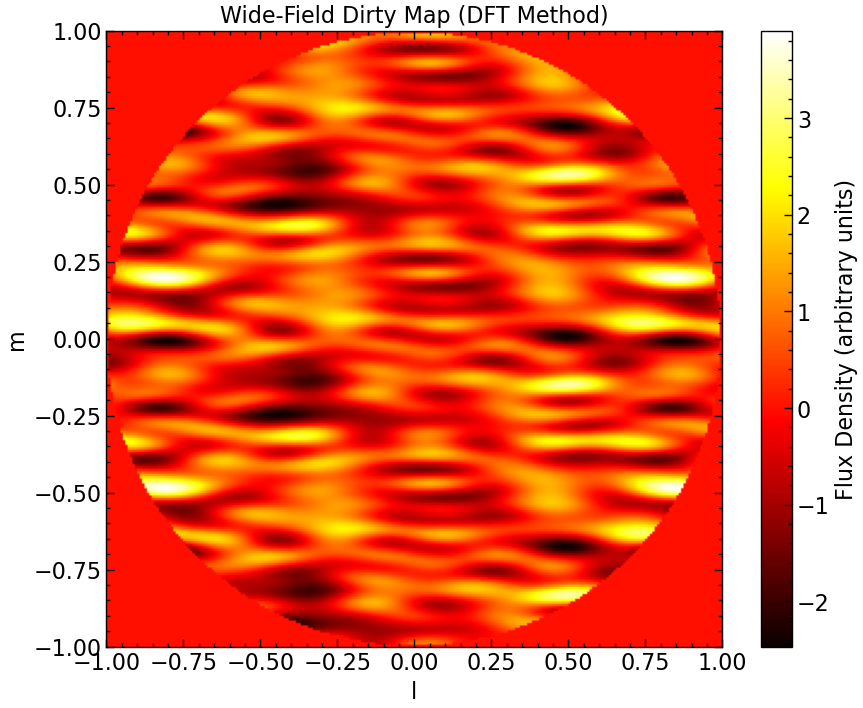

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def generate_dirty_map_v2(vis, uvw_lambda, res=256):
    """
    DFT imaging for data where UVW is (baseline, freq, 3) in wavelengths.
    
    Parameters:
    vis: array (time, baseline, freq, pol, pol)
    uvw_lambda: array (baseline, freq, 3) - assumed in units of lambda
    res: pixel resolution
    """
    # 1. Setup l, m, n grid
    l_axis = np.linspace(-1, 1, res)
    m_axis = np.meshgrid(l_axis, l_axis) # Simple way to get L, M
    L, M = m_axis[0], m_axis[1]
    
    dist_sq = L**2 + M**2
    horizon_mask = dist_sq <= 1.0
    
    l_flat = L[horizon_mask]
    m_flat = M[horizon_mask]
    n_flat = np.sqrt(1.0 - dist_sq[horizon_mask])
    
    # 2. Average visibilities over time
    # Resulting shape: (baseline, freq)
    # avg_vis = np.mean(vis[:, :, :, 0, 0], axis=0) 
    # avg_vis = vis[0,:,:,0,0]
    
    n_baselines = vis.shape[0]
    n_freqs = vis.shape[1]
    
    # print(f"Processing {n_baselines} baselines over {n_freqs} frequency channels...")
    
    sky_brightness = np.zeros(len(l_flat), dtype=complex)
    
    # 3. DFT Loop over frequencies
    for f_idx in range(n_freqs):
        # Extract u, v, w in wavelengths for this channel
        u = uvw_lambda[:, f_idx, 0]
        v = uvw_lambda[:, f_idx, 1]
        w = uvw_lambda[:, f_idx, 2]
        
        # Extract visibilities for this channel
        v_chan = vis[:, f_idx]
        
        # Vectorized phase calculation for all pixels
        # Equation: exp(2πi * [ul + vm + w(n-1)])
        # Use np.dot for the summation over baselines
        # This computes the contribution of all baselines to all pixels at once
        phase_arg = 2j * np.pi * (
            np.outer(l_flat, u) + 
            np.outer(m_flat, v) + 
            np.outer(n_flat - 1, w)
        )
        
        # Add the contribution of this frequency to the map
        sky_brightness += np.dot(np.exp(phase_arg), v_chan)
        # print(f"Processing completed for {f_idx}")

    # 4. Final Image Reconstruction
    dirty_map = np.zeros((res, res))
    # Normalize by total number of measurements (baselines * channels)
    dirty_map[horizon_mask] = np.real(sky_brightness) / (n_baselines * n_freqs)
    
    return dirty_map

import cupy as cp

def generate_dirty_map_gpu_chunked(vis, uvw_lambda, res=256, chunk_size=2000):
    """
    GPU DFT imaging with pixel chunking to prevent OutOfMemoryErrors.
    """
    # 1. Setup grid on GPU
    l_axis = cp.linspace(-1, 1, res)
    L, M = cp.meshgrid(l_axis, l_axis)
    dist_sq = L**2 + M**2
    horizon_mask = dist_sq <= 1.0
    
    l_flat = L[horizon_mask].astype(cp.float32)
    m_flat = M[horizon_mask].astype(cp.float32)
    n_flat = cp.sqrt(1.0 - dist_sq[horizon_mask]).astype(cp.float32)
    
    # 2. Transfer data to GPU (Using float32/complex64)
    v_gpu = cp.asarray(vis, dtype=cp.complex64)
    uvw_gpu = cp.asarray(uvw_lambda, dtype=cp.float32)
    
    n_pixels = len(l_flat)
    n_baselines = v_gpu.shape[0]
    n_freqs = v_gpu.shape[1]
    
    # Final result array on GPU
    sky_brightness = cp.zeros(n_pixels, dtype=cp.complex64)
    
    # 3. Process in pixel chunks
    for i in range(0, n_pixels, chunk_size):
        end = min(i + chunk_size, n_pixels)
        l_chunk = l_flat[i:end]
        m_chunk = m_flat[i:end]
        n_chunk = n_flat[i:end]
        
        chunk_sum = cp.zeros(end - i, dtype=cp.complex64)
        
        # Loop over frequencies for this chunk of pixels
        for f_idx in range(n_freqs):
            u = uvw_gpu[:, f_idx, 0]
            v = uvw_gpu[:, f_idx, 1]
            w = uvw_gpu[:, f_idx, 2]
            v_chan = v_gpu[:, f_idx]
            
            # Phase calculation for the chunk: (chunk_size, n_baselines)
            # Using exp(j * theta) = cos(theta) + j*sin(theta) can sometimes be faster,
            # but cp.exp is generally well-optimized.
            phase_arg = 2.0 * cp.pi * (
                cp.outer(l_chunk, u) + 
                cp.outer(m_chunk, v) + 
                cp.outer(n_chunk - 1.0, w)
            )
            
            # Dot product: (chunk_size, baselines) @ (baselines,) -> (chunk_size,)
            chunk_sum += cp.dot(cp.exp(1j * phase_arg.astype(cp.float32)), v_chan)
            
        sky_brightness[i:end] = chunk_sum
        
        # Clear the cache occasionally if VRAM is tight
        cp.get_default_memory_pool().free_all_blocks()

    # 4. Final Reconstruction
    dirty_map = cp.zeros((res, res), dtype=cp.float32)
    dirty_map[horizon_mask] = cp.real(sky_brightness) / (n_baselines * n_freqs)
    
    return cp.asnumpy(dirty_map)

# Run the imaging
# Note: Ensure mod_vis and uvw_coords are passed correctly
t = 0
vis = mod_vis[0,:,:,0,0]
dirty_map = generate_dirty_map_gpu_chunked(vis, uvw_coords, res=256)

# Plotting the result
plt.figure(figsize=(10, 8))
plt.imshow(dirty_map, extent=[-1, 1, -1, 1], origin='lower', cmap='hot')
plt.colorbar(label='Flux Density (arbitrary units)')
plt.title('Wide-Field Dirty Map (DFT Method)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

In [7]:
vis.shape

(1830, 1)

In [41]:
res=256
l_axis = np.linspace(-1, 1, res)
m_axis = np.meshgrid(l_axis, l_axis)
L, M = m_axis[0], m_axis[1]

dist_sq = L**2 + M**2
horizon_mask = dist_sq <= 1.0
sigma = np.std(dirty_map[horizon_mask])
print(sigma)

0.97981393


In [42]:
pixs = []
for t in range(mod_vis.shape[0]):
    vis = mod_vis[t,:,:,0,0]
    dirty_map = generate_dirty_map_gpu_chunked(vis, uvw_coords, res=256)
    center_pixel = dirty_map[res//2, res//2]
    pixs.append(center_pixel)
np.std(pixs)

np.float32(0.8712667)

In [43]:
np.std(vis.real),np.std(vis.imag)


(np.float64(43.572252932111155), np.float64(43.39880512632655))

In [44]:
k_B = 1.380649e-23

# Per-antenna effective area
A_eff_ant = 0.20  # m^2  (example value)

# System temperature per frequency
Tsky_eff_k = 0
Trec_k = 50
Tsys = Trec_k + Tsky_eff_k   # vector (n_freq,)

# SEFD per frequency (Jy)
sefd = (2 * k_B * Tsys / A_eff_ant) * 1e26

df_hz = 125e6
integration_time_s = 1

In [45]:
sigma_theory = (
    sefd
    / np.sqrt(2 * df_hz * integration_time_s)
    # / np.sqrt(1830 * 1)
)
sigma_theory

np.float64(43.659954892338135)

In [25]:
np.std(vis.real)

np.float64(483.60932737499456)

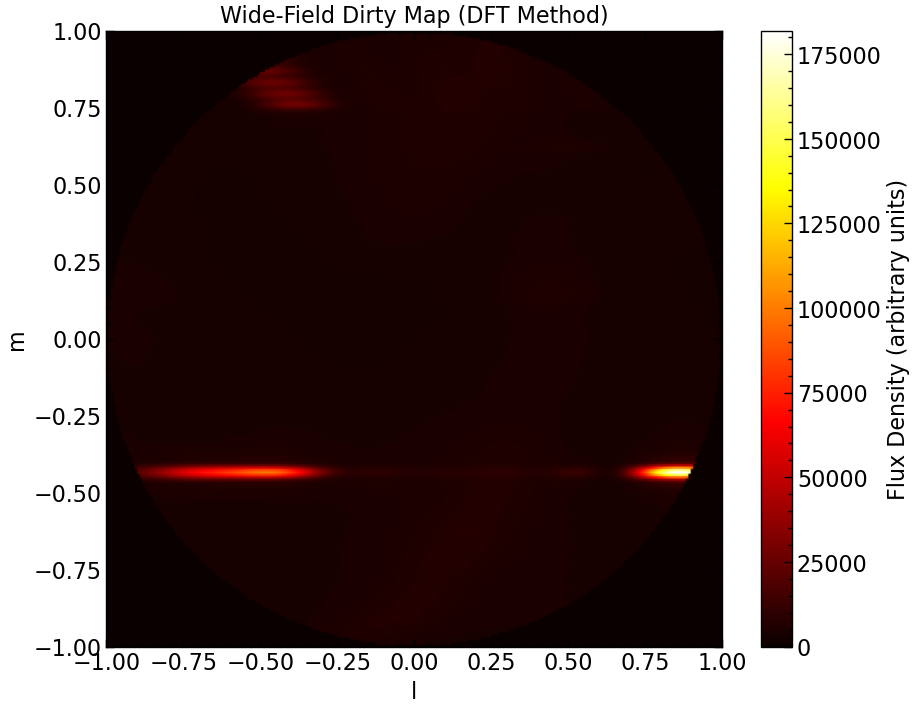

In [36]:
t = 0
vis = mod_vis[0,:,:,0,0]
dirty_map = generate_dirty_map_gpu_chunked(vis, uvw_coords, res=256)

# Plotting the result
plt.figure(figsize=(10, 8))
plt.imshow(dirty_map, extent=[-1, 1, -1, 1], origin='lower', cmap='hot')
plt.colorbar(label='Flux Density (arbitrary units)')
plt.title('Wide-Field Dirty Map (DFT Method)')
plt.xlabel('l')
plt.ylabel('m')
plt.show()

In [56]:
def transform_to_alt_az(dirty_map, res=256):
    # 1. Create the original (l, m) coordinates for every pixel
    l_axis = np.linspace(-1, 1, res)
    L, M = np.meshgrid(l_axis, l_axis)
    
    # Flatten the map and coordinates for interpolation
    l_flat = L.flatten()
    m_flat = M.flatten()
    data_flat = dirty_map.flatten()
    
    # 2. Define the new Alt-Az grid
    # Azimuth from 0 to 360 degrees
    # Altitude from 0 to 90 degrees
    az_new = np.linspace(0, 2 * np.pi, res)
    alt_new = np.linspace(0, np.pi / 2, res // 2)
    AZ, ALT = np.meshgrid(az_new, alt_new)
    
    # 3. Convert the new Alt-Az grid back to (l, m) to find where to sample
    # l = cos(Alt) * sin(Az)
    # m = cos(Alt) * cos(Az)
    L_target = np.cos(ALT) * np.sin(AZ)
    M_target = np.cos(ALT) * np.cos(AZ)
    
    # 4. Interpolate from (l_flat, m_flat) to (L_target, M_target)
    # This maps the rectangular dirty_map onto the polar projection
    alt_az_map = griddata((l_flat, m_flat), data_flat, (L_target, M_target), method='linear')
    
    return az_new, alt_new, alt_az_map

In [57]:
def plot_srcs(t):
    cs = ["xkcd:azure", "k","xkcd:red","xkcd:orange"]
    for src, i in zip(source_names[0], range(len(source_names))):
        if src == "Cyg A":
            continue
        else:
            # print(src,i)
            ax.plot(np.deg2rad(src_azs[t,i]),(90-src_alts[t,i]), c = cs[i], marker = "*", label = source_names[0,i])


In [58]:
def skyplot(t, sig):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')

    vis = mod_vis[t,:,:,0,0]
    dirty_map = generate_dirty_map_gpu_chunked(vis, uvw_coords, res=256)

    # Execute Transformation
    az_axis, alt_axis, alt_az_data = transform_to_alt_az(dirty_map, res=256)

    alt_az_data_clipped = sigma_clip(alt_az_data, sigma = sig)
    # mesh = ax.pcolormesh(az_axis, 90 - np.degrees(alt_axis), alt_az_data, cmap='hot', shading='auto', vmin=24e3, vmax=vmax)
    mesh = ax.pcolormesh(az_axis, 90 - np.degrees(alt_axis), alt_az_data_clipped, cmap='gray_r')

    utc_dt = datetime.datetime.fromisoformat(mod_times[t]).replace(tzinfo=pytz.utc)

    # Define Pacific timezone
    pacific_tz = pytz.timezone('America/Los_Angeles')
    local_dt = utc_dt.astimezone(pacific_tz)
    local_dt = local_dt.strftime('%Y-%m-%d %H:%M:%S')

    # sun_alt, sun_az = sun_alts[t], sun_azs[t]
    # ax.plot(np.deg2rad(sun_az),(90-sun_alt), "k*")
    # ax.set_theta_direction(-1)
    cs = ["xkcd:azure", "k","xkcd:red","xkcd:orange"]
    for src, i in zip(source_names[0], range(len(source_names))):
        if src == "Cyg A":
            continue
        else:
            # print(src,i)
            ax.plot(np.deg2rad(src_azs[t,i]),(90-src_alts[t,i]), c = cs[i], marker = "*", label = source_names[0,i])
    ax.legend(fontsize = 10)
    ax.set_theta_zero_location("N") # Sets North to the top
    # ax.set_theta_direction(-1)     # Sets Azimuth to increase clockwise
    ax.set_rlabel_position(225)    # Move radial labels
    ax.set_title(f"Sky Map at {local_dt}", va='bottom')

    plt.colorbar(mesh, label='Flux Density')
    # plt.show()
    return fig

In [59]:
def skyplot_log(t, sig):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')

    vis = mod_vis[t,:,:,0,0]
    dirty_map = generate_dirty_map_gpu_chunked(vis, uvw_coords, res=256)

    # Execute Transformation
    az_axis, alt_axis, alt_az_data = transform_to_alt_az(dirty_map, res=256)
    alt_az_data = np.log(alt_az_data + 1e-6)  # Add small value to avoid log(0)
    alt_az_data_clipped = sigma_clip(alt_az_data, sigma = sig)
    # mesh = ax.pcolormesh(az_axis, 90 - np.degrees(alt_axis), alt_az_data, cmap='hot', shading='auto', vmin=24e3, vmax=vmax)
    mesh = ax.pcolormesh(az_axis, 90 - np.degrees(alt_axis), alt_az_data_clipped, cmap='gray_r')

    utc_dt = datetime.datetime.fromisoformat(mod_times[t]).replace(tzinfo=pytz.utc)

    # Define Pacific timezone
    pacific_tz = pytz.timezone('America/Los_Angeles')
    local_dt = utc_dt.astimezone(pacific_tz)
    local_dt = local_dt.strftime('%Y-%m-%d %H:%M:%S')

    # sun_alt, sun_az = sun_alts[t], sun_azs[t]
    # ax.plot(np.deg2rad(sun_az),(90-sun_alt), "k*")
    # ax.set_theta_direction(-1)
    cs = ["xkcd:azure", "k","xkcd:red","xkcd:orange"]
    for src, i in zip(source_names[0], range(len(source_names))):
        if src == "Cyg A":
            continue
        else:
            # print(src,i)
            ax.plot(np.deg2rad(src_azs[t,i]),(90-src_alts[t,i]), c = cs[i], marker = "*", label = source_names[0,i])
    ax.legend(fontsize = 10)
    ax.set_theta_zero_location("N") # Sets North to the top
    # ax.set_theta_direction(-1)     # Sets Azimuth to increase clockwise
    ax.set_rlabel_position(225)    # Move radial labels
    ax.set_title(f"Sky Map at {local_dt}", va='bottom')

    plt.colorbar(mesh, label='Flux Density')
    # plt.show()
    return fig

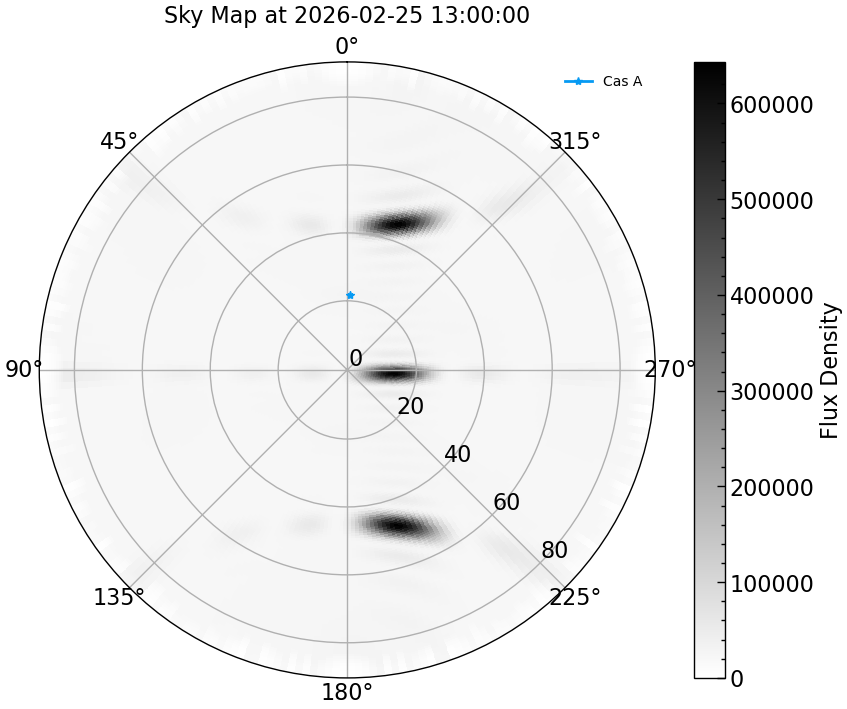

In [60]:
fig = skyplot(1,50)
# fig.savefig("test.png")

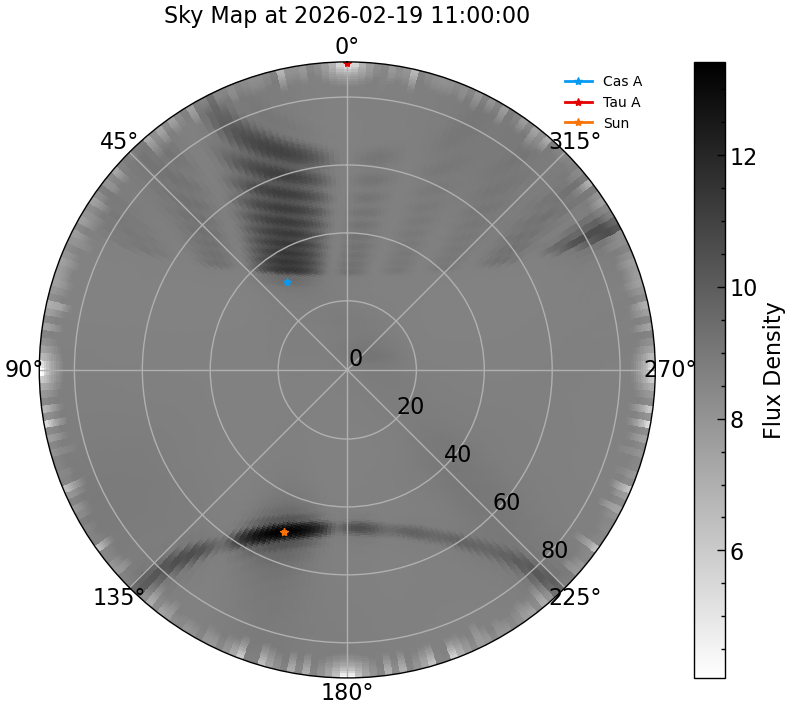

In [52]:
fig = skyplot_log(3,10)


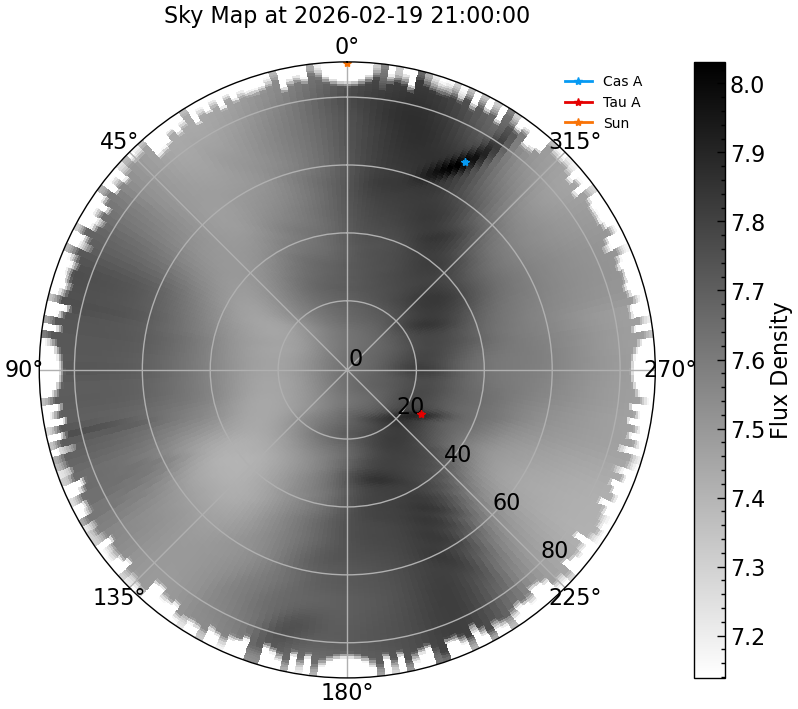

In [55]:
fig = skyplot_log(13,4)


In [ ]:
for t in range(24):
    if t < 10 or t == 23:
        # continue
        fig = skyplot(t,20)
        fig.savefig(f"sky2/{t}.png", dpi = 200)
        plt.close()
    else:
        fig = skyplot(t,4)
        fig.savefig(f"sky2/{t}.png", dpi = 200)
        plt.close()
        # fig.close()

In [57]:
for t in range(24):
    if t < 10 or t == 23:
        # continue
        fig = skyplot_log(t,10)
        fig.savefig(f"sky2/{t}.png", dpi = 200)
        plt.close()
    else:
        fig = skyplot_log(t,5)
        fig.savefig(f"sky2/{t}.png", dpi = 200)
        plt.close()
        # fig.close()

In [58]:
import imageio.v3 as iio
import os
import re
import numpy as np
from PIL import Image

image_folder = 'sky2/'
filenames = [f for f in os.listdir(image_folder) if f.endswith('.png')]
filenames.sort(key=lambda x: int(re.findall(r'\d+', x)[0]))

# Prepare frames
frames = []
first_img = Image.open(os.path.join(image_folder, filenames[0]))
target_size = first_img.size

for f in filenames:
    img = Image.open(os.path.join(image_folder, f)).convert('RGB') # Remove alpha channel
    if img.size != target_size:
        img = img.resize(target_size, Image.Resampling.LANCZOS)
    frames.append(np.array(img))

# Save as high-quality MP4
# fps: frames per second
iio.imwrite('sky_rotation_258.mp4', np.stack(frames), fps=5, codec='libx264', quality=8)

print("MP4 created. This should look much smoother than the GIF.")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1579, 1413) to (1584, 1424) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


MP4 created. This should look much smoother than the GIF.


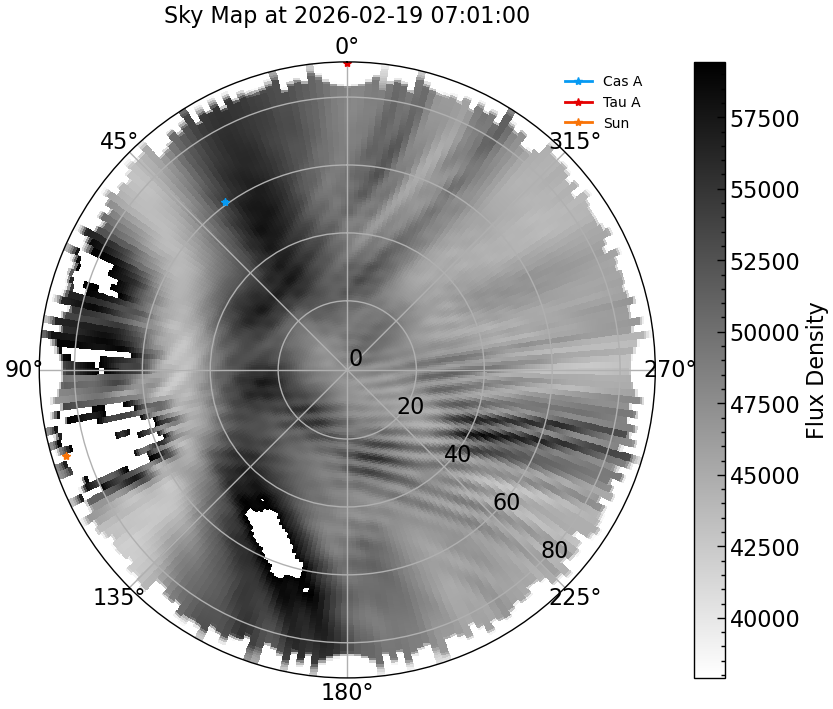

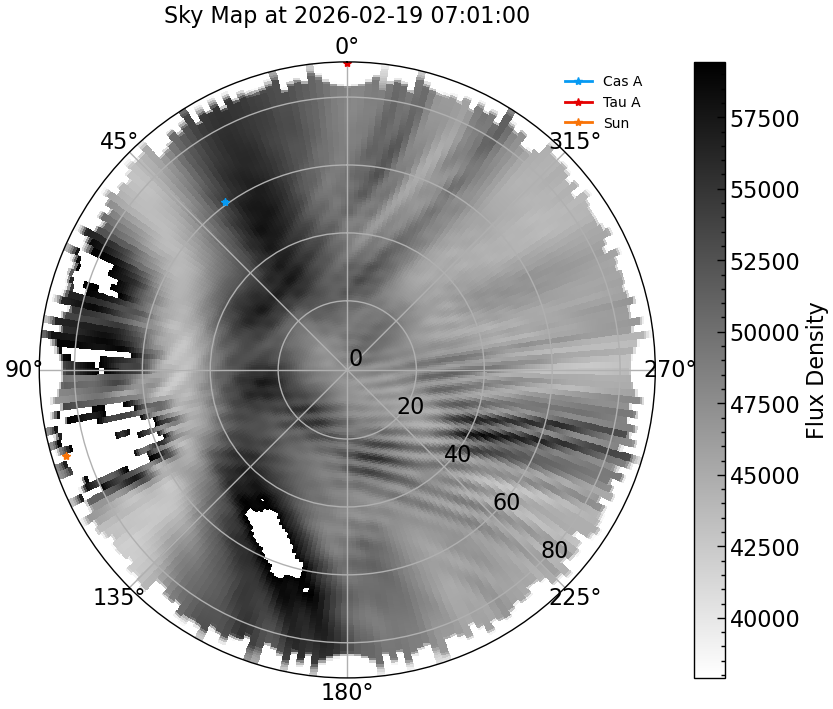

In [48]:
skyplot(23,3)

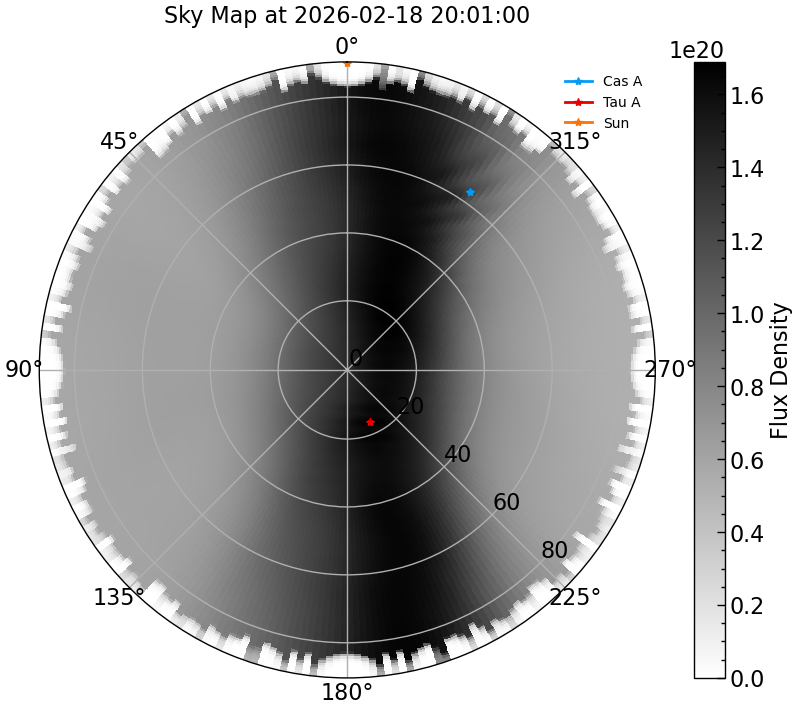

In [33]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

t = 12
vis = mod_vis[t,:,:,0,0]
# dirty_map = generate_dirty_map_v2(vis, uvw_coords, res=256)

# # Execute Transformation
# az_axis, alt_axis, alt_az_data = transform_to_alt_az(dirty_map, res=256)

# Azimuth in matplotlib polar is counter-clockwise, 0 is at the right.
# You may need to offset az_axis depending on your orientation convention.
# Converting Alt to Zenith Angle (90-Alt) for polar plotting if desired,
# or just plot Alt directly.
# zscale = ZScaleInterval()
# vmin, vmax = zscale.get_limits(alt_az_data)
alt_az_data = (alt_az_data)**1
alt_az_data_clipped = sigma_clip(alt_az_data, sigma = 3)
# mesh = ax.pcolormesh(az_axis, 90 - np.degrees(alt_axis), alt_az_data, cmap='hot', shading='auto', vmin=24e3, vmax=vmax)
mesh = ax.pcolormesh(az_axis, 90 - np.degrees(alt_axis), alt_az_data_clipped, cmap='gray_r')

utc_dt = datetime.datetime.fromisoformat(mod_times[t]).replace(tzinfo=pytz.utc)

# Define Pacific timezone
pacific_tz = pytz.timezone('America/Los_Angeles')
local_dt = utc_dt.astimezone(pacific_tz)
local_dt = local_dt.strftime('%Y-%m-%d %H:%M:%S')

# sun_alt, sun_az = sun_alts[t], sun_azs[t]
# ax.plot(np.deg2rad(sun_az),(90-sun_alt), "k*")
# ax.set_theta_direction(-1)
plot_srcs(t)
ax.legend(fontsize = 10)
ax.set_theta_zero_location("N") # Sets North to the top
# ax.set_theta_direction(-1)     # Sets Azimuth to increase clockwise
ax.set_rlabel_position(225)    # Move radial labels
ax.set_title(f"Sky Map at {local_dt}", va='bottom')

plt.colorbar(mesh, label='Flux Density')
plt.show()

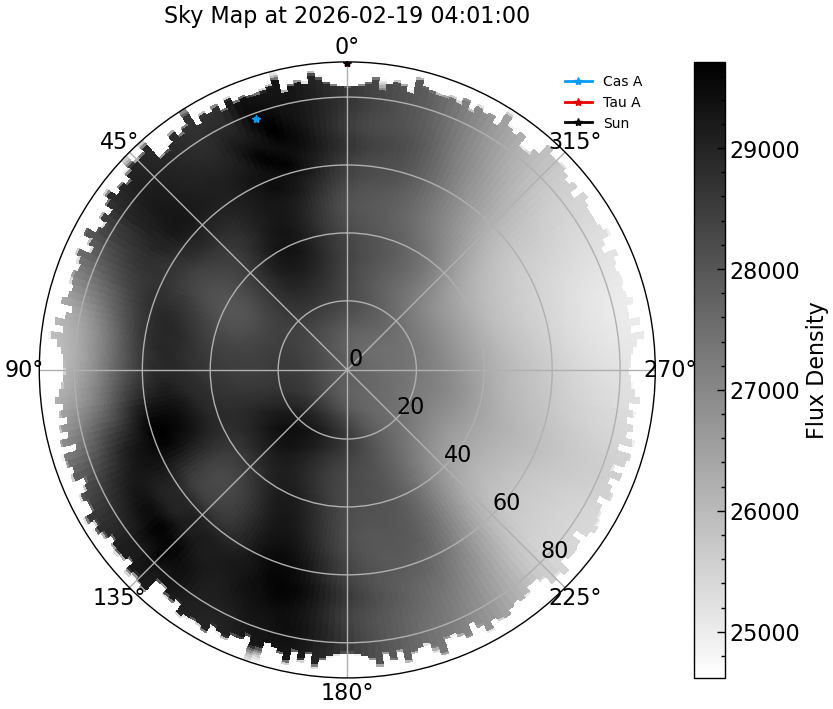

In [18]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

t = 20
vis = mod_vis[t,:,:,0,0]
dirty_map = generate_dirty_map_v2(vis, uvw_coords, res=256)

# Execute Transformation
az_axis, alt_axis, alt_az_data = transform_to_alt_az(dirty_map, res=256)

# Azimuth in matplotlib polar is counter-clockwise, 0 is at the right.
# You may need to offset az_axis depending on your orientation convention.
# Converting Alt to Zenith Angle (90-Alt) for polar plotting if desired,
# or just plot Alt directly.
# zscale = ZScaleInterval()
# vmin, vmax = zscale.get_limits(alt_az_data)
alt_az_data_clipped = sigma_clip(alt_az_data, sigma = 3)
# mesh = ax.pcolormesh(az_axis, 90 - np.degrees(alt_axis), alt_az_data, cmap='hot', shading='auto', vmin=24e3, vmax=vmax)
mesh = ax.pcolormesh(az_axis, 90 - np.degrees(alt_axis), alt_az_data_clipped, cmap='gray_r')

utc_dt = datetime.datetime.fromisoformat(mod_times[t]).replace(tzinfo=pytz.utc)

# Define Pacific timezone
pacific_tz = pytz.timezone('America/Los_Angeles')
local_dt = utc_dt.astimezone(pacific_tz)
local_dt = local_dt.strftime('%Y-%m-%d %H:%M:%S')

# sun_alt, sun_az = sun_alts[t], sun_azs[t]
# ax.plot(np.deg2rad(sun_az),(90-sun_alt), "k*")
# ax.set_theta_direction(-1)
plot_srcs(t)
ax.legend(fontsize = 10)
ax.set_theta_zero_location("N") # Sets North to the top
# ax.set_theta_direction(-1)     # Sets Azimuth to increase clockwise
ax.set_rlabel_position(225)    # Move radial labels
ax.set_title(f"Sky Map at {local_dt}", va='bottom')

plt.colorbar(mesh, label='Flux Density')
plt.show()